# Mixed Galerkin: a Cauer ladder that reaches deep skin

The eddy-current admittance `Y(s)` of a conductor has to hold from DC to
deep skin effect. A Cauer ladder network is the standard reduction, and a
finite ladder is a **rational** function of `s` -- so its asymptotic slope
is an integer, while the physics decays as `f^(-1/2)`. No number of rungs
fixes that, and neither do extra expansion points, because every finite
expansion point yields another rational basis.

The reason is visible in the `s` plane. The bulk contributes **poles** at
`s = -lambda_n`, the diffusion eigenvalues. The square-root tail is not a
pole at all: `1/sqrt(s)` has a branch point, so it has no Laurent
expansion and no residue. In Stieltjes form

$$\frac{1}{\sqrt{s}}=\frac{1}{\pi}\int_{0}^{\infty}\frac{\xi^{-1/2}}{s+\xi}\,d\xi$$

it is a *continuum* of poles, each carrying infinitesimal weight. A finite
sum of point masses cannot equal a continuous density.

So use both: bulk CLN Krylov modes, which do not depend on frequency and
are built once, plus surface envelopes `psi ~ exp(-d(r)/delta(s))`, which
do depend on frequency and carry the square root. Eliminating the bulk
block gives the Schur complement, which is the discrete
Steklov-Poincare (DtN) map and the surface-port admittance -- and the
crossover between ladder and square root comes out of that projection
rather than being fitted.

This notebook is a **showcase**: it shows what the method reaches and what
it does not. It owns no numbers. Everything quantitative is read from the
artifact that `validation_test/mixed_galerkin/` writes.


In [1]:
import json
from pathlib import Path

REPO = Path.cwd()
while not (REPO / 'validation_test').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
ART = (REPO / 'validation_test' / 'mixed_galerkin' / 'results'
       / 'mixed_galerkin_results.json')

results = json.loads(ART.read_text(encoding='utf-8'))
print('artifact :', ART.relative_to(REPO).as_posix())
print('written  :', results['generated_at_utc'])
print('metric   :', results['cases']['cylinder_planar_sibc']['metric'])
print('owner    :', results['owner'])


artifact : validation_test/mixed_galerkin/results/mixed_galerkin_results.json
written  : 2026-09-02T02:33:18.048639+00:00
metric   : abs(Y_exact - Y_mixed) / abs(Y_exact)
owner    : validation_test/mixed_galerkin -- documentation and talk material read this file and must not recompute it


## What it reaches

One error metric throughout, stated in the artifact itself: the **complex**
relative difference `abs(Y_exact - Y_mixed) / abs(Y_exact)`, maximised over
1 Hz to 100 MHz. Taking `abs()` of each side before subtracting would drop
the phase error and report a smaller number.


In [2]:
rows = []
c = results['cases']
rows.append(('cylinder', 'planar SIBC, 1 surface DOF',
             c['cylinder_planar_sibc']['max_error_pct']))
for n, r in sorted(c['cylinder_senior_tower']['by_n_dof'].items()):
    rows.append(('cylinder', f'Senior tower, {n} surface DOF',
                 r['max_error_pct']))
rows.append(('sphere', 'planar SIBC, 1 surface DOF',
             c['sphere_hoibc_gamma1']['planar_max_error_pct']))
rows.append(('sphere', 'plus curvature gamma_1',
             c['sphere_hoibc_gamma1']['gamma1_max_error_pct']))
rows.append(('2-D square', 'tensor corner envelope',
             c['square2d_corner_envelope']['max_error_pct']))

print(f"{'body':12s} {'surface basis':30s} {'worst error':>13s}")
for body, basis, err in rows:
    print(f'{body:12s} {basis:30s} {err:12.5f} %')

g = c['sphere_hoibc_gamma1']
print()
print(f"sphere, one curvature term: "
      f"{g['improvement_factor_max_anywhere']:.1f}x over the whole band, "
      f"{g['improvement_factor_wall_band']:.1f}x in the wall band")


body         surface basis                    worst error
cylinder     planar SIBC, 1 surface DOF          0.06386 %
cylinder     Senior tower, 1 surface DOF         0.06386 %
cylinder     Senior tower, 2 surface DOF         0.01233 %
cylinder     Senior tower, 3 surface DOF         0.00270 %
cylinder     Senior tower, 4 surface DOF         0.00063 %
sphere       planar SIBC, 1 surface DOF          0.13712 %
sphere       plus curvature gamma_1              0.00372 %
2-D square   tensor corner envelope              0.33754 %

sphere, one curvature term: 36.9x over the whole band, 102.2x in the wall band


## The curves

Drawn by calling the same `Y_mixed_galerkin` the validation lane calls.
Sharing an implementation is fine; it is duplicating a *measurement* that
lets two answers drift apart.


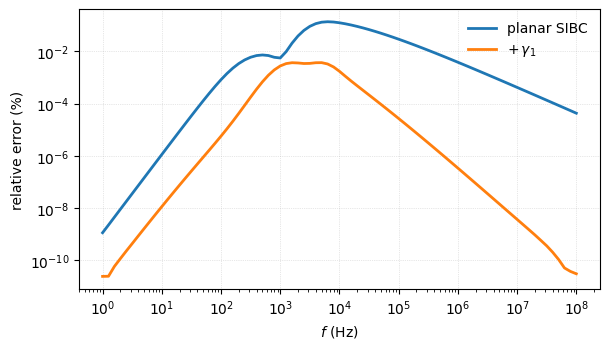

planar SIBC      max 0.1371 % at f = 6.31e+03 Hz
$+\,\gamma_1$    max 0.0037 % at f = 5.01e+03 Hz


In [3]:
import importlib.util
import math
import numpy as np
import matplotlib.pyplot as plt

MG = REPO / 'validation_test' / 'mixed_galerkin'


def case(rel):
    spec = importlib.util.spec_from_file_location(
        'mg_' + rel.replace('/', '_')[:-3], MG / rel)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


SPH = case('sphere/02_hoibc_gamma1.py')
from radia.maglev.mixed_galerkin.references import Y_exact_sphere

fs = np.logspace(0, 8, 81)
err = {}
for label, g1 in (('planar SIBC', False), (r'$+\,\gamma_1$', True)):
    e = []
    for f in fs:
        s = 1j * 2 * math.pi * f
        Ye = Y_exact_sphere(s, SPH.A, SPH.SIGMA, SPH.MU)
        e.append(abs(Ye - SPH.Y_mixed_galerkin(s, g1)) / abs(Ye) * 100)
    err[label] = np.array(e)

fig, ax = plt.subplots(figsize=(6.2, 3.6))
for label, e in err.items():
    ax.loglog(fs, e, lw=2.0, label=label)
ax.set_xlabel('$f$ (Hz)')
ax.set_ylabel('relative error (%)')
ax.grid(True, which='major', ls=':', lw=0.5, alpha=0.6)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

for label, e in err.items():
    print(f'{label:16s} max {e.max():.4f} % at f = {fs[e.argmax()]:.2e} Hz')


## What it does not reach

On a polyhedron the error stops at 0.33 % against an NGSolve FEM solution
(cube, rank-20 bulk). The reason is not a missing shape. The tensor
envelope `psi = f(x) f(y) f(z)` already has the right asymptotic form in
all three places:

| where | asymptote | correct? |
|---|---|---|
| face | `exp(-d t) - 1`, the slab SIBC envelope | yes |
| edge, two faces | `r^2 sin(2 theta)`, the Wiener-Hopf wedge | yes |
| corner, three faces | `x y z ~ r^3 Y_{3,0}`, the octant eigenfunction | yes |

What one coefficient cannot do is weight all three correctly at once. The
obvious repair -- give each boundary class its own coefficient, seven
envelopes instead of one -- **was tried and fails**: at high frequency those
seven are not linearly independent, the Gram matrix becomes
ill-conditioned, and the solve returns garbage
(`validation_test/mixed_galerkin/cube3d/08_edge_corner_basis.py`). An edge
needs a basis with genuine two-dimensional structure across it, which is
what `09_wedge_basis.py` attempts and is open.

In two dimensions, where there is no trihedral corner, the same
construction reaches 0.34 %.

Non-tensor bodies are open for a related reason: on an L-shape a
bounding-box envelope does not satisfy the boundary condition on the
concave step faces, and adding it makes the answer worse rather than
better (+21 % to +67 % against FEM).

Everything here is linear, isotropic and non-magnetic.


## Where things live

| what | where |
|---|---|
| public API | `radia.maglev.mixed_galerkin` -- bulk Foster basis from a mesh, CAD edge topology, `Y_mixed`, Foster ROM fit, state space |
| reference solutions | `radia.maglev.mixed_galerkin.references` -- exact cylinder and sphere, and `Y_cln_pade` for the truncated ladder |
| validation cases | `validation_test/mixed_galerkin/`, each exposing `summary()` |
| the numbers | `validation_test/mixed_galerkin/results/mixed_galerkin_results.json`, written by `emit_results.py` |
| golden | `tests/test_maglev_mixed_galerkin_golden.py` |

This notebook reads the artifact and does not recompute it. That rule
exists because it was broken: a figure script that recomputed the same
errors reported 0.0525 % where the validation lane reported 0.0639 %, on
the same grid with the same solver, because it differenced magnitudes
instead of complex values.
